# IMDB Movie Reviews — dataset check

Basic load of the raw CSV to confirm it parses and see how many records we start with.

In [2]:
import os
from pathlib import Path

# transformers probes for TensorFlow on import; the installed TF 2.13 is not
# compatible with protobuf 6.x. This is a torch-only project, so skip the probe.
os.environ["USE_TF"] = "0"

import pandas as pd

DATA_PATH = Path("..") / "data" / "IMDB-movie-reviews.csv"

# Semicolon-delimited, and the file is cp1252-encoded (not UTF-8).
df = pd.read_csv(DATA_PATH, sep=";", encoding="cp1252")

print(f"Records: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Records: 100
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(df["sentiment"].value_counts())
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

sentiment
negative    58
positive    42
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows: 0


In [4]:
# Split into features and target.
X = df["review"]
y_target = df["sentiment"]

print(f"X: {X.shape}, y_target: {y_target.shape}")


X: (100,), y_target: (100,)


# Model 1
Based on the requirements I decided to pick the distilbert-base-uncased-finetuned-sst-2-english. This is 66 million parameter model distilled from the original BERT model. It reaches similar accuracy, but with less parameters (66M vs 110M). It is also faster. 

The model is transformer based which gives it several advantages:
- It is actually able to capture context, it does not just do key-word counting.
- Deals with Negation (great vs not great).
- Still very capable to run on ordinary CPU's 

In [5]:
# Create a sentiment analysis pipeline using the DistilBERT model fine-tuned on the SST-2 dataset. The pipeline will run on the Metal Performance Shaders (MPS) device if available, which is suitable for macOS users with Apple Silicon.
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device='mps')


y_pred = classifier(X.tolist(), truncation=True)

/Users/indy/miniconda3/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [6]:
from sklearn.metrics import accuracy_score, classification_report

# The pipeline returns [{'label': 'POSITIVE'|'NEGATIVE', 'score': ...}], so lower-case
# the labels to line them up with y_target's 'positive'/'negative'.
y_pred_labels = [p["label"].lower() for p in y_pred]

n_correct = (y_target == y_pred_labels).sum()
accuracy = accuracy_score(y_target, y_pred_labels)

print(f"Accuracy: {accuracy:.1%}  ({n_correct}/{len(y_target)} correct)")
print()
print(classification_report(y_target, y_pred_labels, digits=3))

Accuracy: 89.0%  (89/100 correct)

              precision    recall  f1-score   support

    negative      0.862     0.966     0.911        58
    positive      0.943     0.786     0.857        42

    accuracy                          0.890       100
   macro avg      0.902     0.876     0.884       100
weighted avg      0.896     0.890     0.888       100



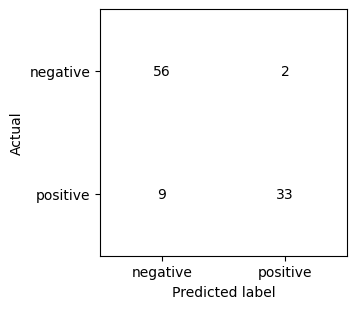

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3.2, 3.2))

# from_predictions needs the label strings, not the raw pipeline dicts, so reuse
# y_pred_labels from the cell above. Pin the label order so the matrix reads in the
# same order as the classification report.
disp = ConfusionMatrixDisplay.from_predictions(
    y_target,
    y_pred_labels,
    labels=["negative", "positive"],
    ax=ax,
    cmap=ListedColormap(["white"]),  # plain cells, no heatmap shading
    colorbar=False,
    text_kw={"color": "black"},  # the shading-based text colour would be white on white
)
ax.set_ylabel("Actual")


plt.show()

## Export predictions

Write the per-review predictions to `notebook_outputs/` so the results can be
inspected outside the notebook.

In [8]:
OUTPUT_PATH = Path("..") / "notebook_outputs" / "distilbert_sst2_predictions.csv"

# y_pred holds the raw pipeline dicts; the score is the confidence for the label
# the model actually picked.
predictions = pd.DataFrame(
    {
        "Review": X,
        "y_target": y_target,
        "y_pred": y_pred_labels,
        "confidence": [p["score"] for p in y_pred],
    }
)

predictions.to_csv(OUTPUT_PATH, index=False)

print(f"Wrote {len(predictions)} rows to {OUTPUT_PATH}")
predictions.head()

Wrote 100 rows to ../notebook_outputs/distilbert_sst2_predictions.csv


,Review,y_target,y_pred,confidence
0,One of the other reviewers has mentioned that ...,positive,negative,0.512120
1,A wonderful little production. <br /><br />The...,positive,positive,0.999377
2,I thought this was a wonderful way to spend ti...,positive,positive,0.999190
3,Basically there's a family where a little boy ...,negative,negative,0.999172
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,positive,0.998824


## Conclusions
- Overall precision on the dataset is 89%
- We need to use truncation because 15/100 datapoints exceed max token input of 512. An improvement could be made here.
- The confusion matrix shows that on this dataset we get more false negatives compared to false positives.
